# 01 - Data Ingestion and EDA (NASA C-MAPSS)

This notebook covers Phase 1 of the implementation plan:
- Loading FD00x train/test/rul files
- Building piecewise-linear RUL targets with configurable capping
- Running sensor variability diagnostics to justify sensor dropping decisions

## Colab setup

If running in Google Colab, mount Drive and install dependencies before executing the notebook cells.

Example:
```bash
pip install -r requirements.txt
```

In [1]:
from pathlib import Path
import sys


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing src/ and data/.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

PosixPath('/Users/ayushkanyal/Desktop/Predictive Maintainence')

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from src.data.constants import RECOMMENDED_DROPPED_SENSORS
from src.data.ingestion import load_fd_dataset
from src.data.rul import add_rul_targets
from src.features.sensor_analysis import compute_sensor_summary, suggest_low_variance_sensors

pd.set_option("display.max_columns", 40)
plt.style.use("seaborn-v0_8-whitegrid")

In [3]:
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

FD_ID = "FD001"
RUL_CAP = 125

print("Raw data directory:", RAW_DIR)
print("Processed data directory:", PROCESSED_DIR)
print("Configured dataset:", FD_ID)
print("Configured RUL cap:", RUL_CAP)

Raw data directory: /Users/ayushkanyal/Desktop/Predictive Maintainence/data/raw
Processed data directory: /Users/ayushkanyal/Desktop/Predictive Maintainence/data/processed
Configured dataset: FD001
Configured RUL cap: 125


In [4]:
required = [
    RAW_DIR / f"train_{FD_ID}.txt",
    RAW_DIR / f"test_{FD_ID}.txt",
    RAW_DIR / f"RUL_{FD_ID}.txt",
]
missing = [p for p in required if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Missing expected raw data files. Place these files in data/raw/:\n"
        + "\n".join(str(p.name) for p in missing)
    )

train_df, test_df, test_rul_df = load_fd_dataset(RAW_DIR, FD_ID)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Test RUL shape:", test_rul_df.shape)

Train shape: (20631, 26)
Test shape: (13096, 26)
Test RUL shape: (100, 2)


In [5]:
train_labeled = add_rul_targets(train_df, cap=RUL_CAP)
train_labeled[["unit_id", "cycle", "rul_raw", "rul"]].head(12)

,unit_id,cycle,rul_raw,rul
0,1,1,191,125
1,1,2,190,125
2,1,3,189,125
3,1,4,188,125
4,1,5,187,125
5,1,6,186,125
6,1,7,185,125
7,1,8,184,125
8,1,9,183,125
9,1,10,182,125


In [6]:
sensor_summary = compute_sensor_summary(train_labeled)
sensor_summary.head(12)

,global_mean,global_std,global_var,global_iqr,mean_unit_std,median_unit_std,max_unit_std
sensor_1,518.670000,0.000000e+00,0.000000e+00,0.0000,0.000000,0.000000,0.000000
sensor_19,100.000000,0.000000e+00,0.000000e+00,0.0000,0.000000,0.000000,0.000000
sensor_18,2388.000000,0.000000e+00,0.000000e+00,0.0000,0.000000,0.000000,0.000000
sensor_16,0.030000,3.469447e-18,1.203706e-35,0.0000,0.000000,0.000000,0.000000
sensor_5,14.620000,5.329071e-15,2.839899e-29,0.0000,0.000000,0.000000,0.000000
sensor_10,1.300000,0.000000e+00,0.000000e+00,0.0000,0.000000,0.000000,0.000000
sensor_6,21.609803,1.388951e-03,1.929186e-06,0.0000,0.000957,0.000763,0.002875
sensor_15,8.442146,3.750413e-02,1.406560e-03,0.0507,0.034377,0.034161,0.042487
sensor_8,2388.096652,7.098376e-02,5.038694e-03,0.0900,0.056452,0.055926,0.089280
sensor_13,2388.096152,7.191717e-02,5.172080e-03,0.1000,0.057124,0.057117,0.092195


In [7]:
auto_drop = suggest_low_variance_sensors(sensor_summary, metric="mean_unit_std", threshold=0.05)
known_drop = set(RECOMMENDED_DROPPED_SENSORS)

print("Auto-detected low-variance sensors (threshold=0.05):")
print(auto_drop)
print()
print("Known sensors from decision log:")
print(sorted(known_drop))
print()
print("Intersection:")
print(sorted(known_drop.intersection(auto_drop)))

Auto-detected low-variance sensors (threshold=0.05):
['sensor_1', 'sensor_19', 'sensor_18', 'sensor_16', 'sensor_5', 'sensor_10', 'sensor_6', 'sensor_15']

Known sensors from decision log:
['sensor_1', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19', 'sensor_5', 'sensor_6']

Intersection:
['sensor_1', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19', 'sensor_5', 'sensor_6']


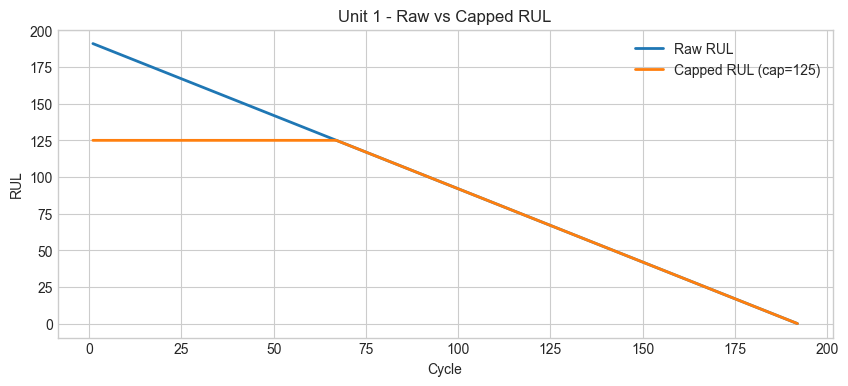

In [8]:
example_unit = int(train_labeled["unit_id"].iloc[0])
example = train_labeled[train_labeled["unit_id"] == example_unit].sort_values("cycle")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(example["cycle"], example["rul_raw"], label="Raw RUL", linewidth=2)
ax.plot(example["cycle"], example["rul"], label=f"Capped RUL (cap={RUL_CAP})", linewidth=2)
ax.set_title(f"Unit {example_unit} - Raw vs Capped RUL")
ax.set_xlabel("Cycle")
ax.set_ylabel("RUL")
ax.legend()
plt.show()

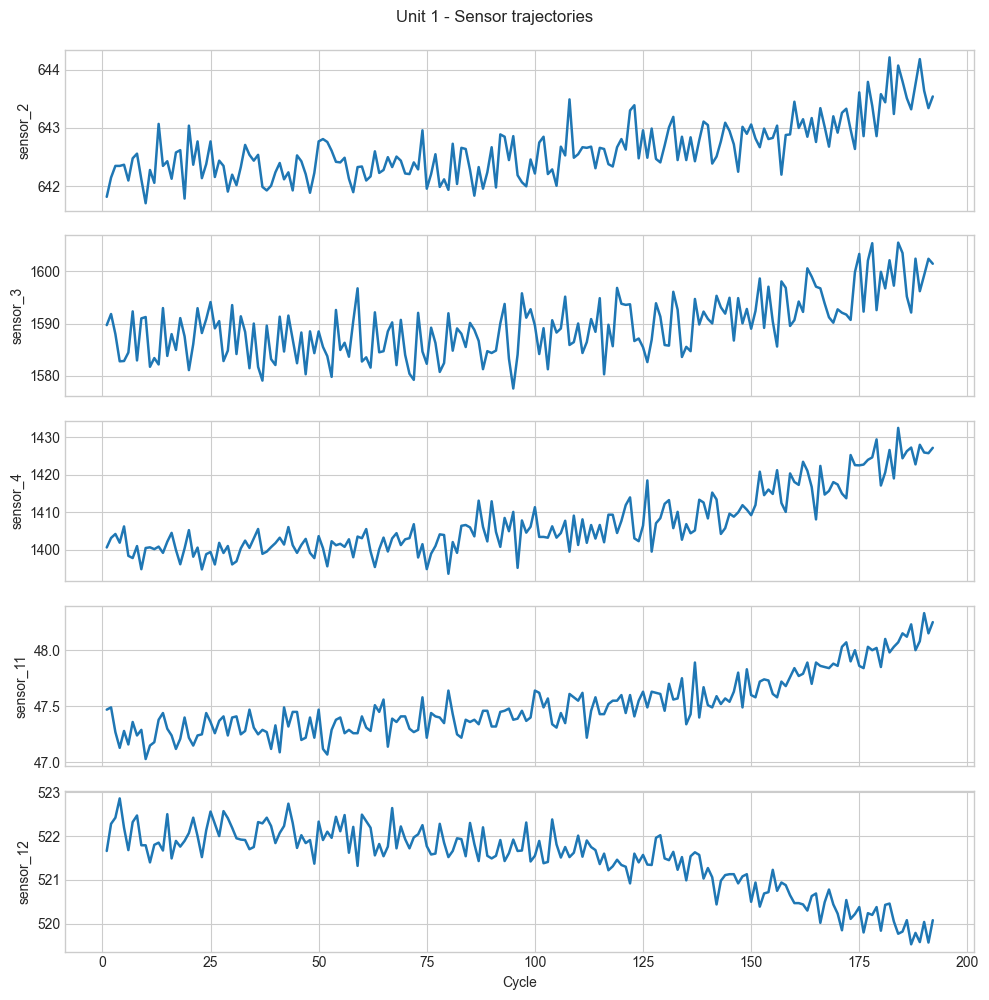

In [9]:
sensors_to_plot = ["sensor_2", "sensor_3", "sensor_4", "sensor_11", "sensor_12"]

fig, axes = plt.subplots(len(sensors_to_plot), 1, figsize=(10, 10), sharex=True)
for idx, sensor in enumerate(sensors_to_plot):
    axes[idx].plot(example["cycle"], example[sensor], linewidth=1.8)
    axes[idx].set_ylabel(sensor)

axes[-1].set_xlabel("Cycle")
fig.suptitle(f"Unit {example_unit} - Sensor trajectories", y=0.995)
plt.tight_layout()
plt.show()

In [10]:
output_path = PROCESSED_DIR / f"train_{FD_ID}_with_rul_cap_{RUL_CAP}.parquet"
train_labeled.to_parquet(output_path, index=False)
print("Saved:", output_path)

Saved: /Users/ayushkanyal/Desktop/Predictive Maintainence/data/processed/train_FD001_with_rul_cap_125.parquet
